In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
# =======================
# 1. Load and prepare data
# =======================
iris = load_iris()
X = iris.data          # shape: (150, 4)
y = iris.target        # shape: (150,)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardise features (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [4]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)  # CrossEntropyLoss expects long
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

In [5]:
# Create DataLoader for batching
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
# =======================
# 2. Define the feedforward network
# =======================
class FeedforwardNN(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
        super(FeedforwardNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, num_classes)
        # No softmax needed because CrossEntropyLoss includes it

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

# Instantiate the model
input_size = 4          # Iris features
hidden_size1 = 10
hidden_size2 = 8
num_classes = 3         # Setosa, Versicolour, Virginica

model = FeedforwardNN(input_size, hidden_size1, hidden_size2, num_classes)

In [7]:
# =======================
# 3. Set loss function and optimizer
# =======================
criterion = nn.CrossEntropyLoss()   # Suitable for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# =======================
# 4. Train the model
# =======================
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

Epoch [20/100], Loss: 0.6636
Epoch [40/100], Loss: 0.3847
Epoch [60/100], Loss: 0.2246
Epoch [80/100], Loss: 0.1248
Epoch [100/100], Loss: 0.0804


In [8]:
# =======================
# 5. Evaluate on test set
# =======================
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'\nTest Accuracy: {accuracy:.2f}%')


Test Accuracy: 96.67%


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time


In [2]:
# ============================
# 1. Set device (GPU if available)
# ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [3]:
# ============================
# 2. Load and preprocess MNIST
# ============================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # mean and std of MNIST
])

# Download and load training dataset
full_train_dataset = datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

# Split into training (80%) and validation (20%)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Test dataset
test_dataset = datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.61MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


In [4]:
# Data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
# ============================
# 3. Define the feedforward network (MLP)
# ============================
class AdvancedMLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[512, 256], num_classes=10, dropout_prob=0.3):
        super(AdvancedMLP, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))   # Batch normalisation
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_prob))      # Dropout for regularisation
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # Flatten the image: (batch, 1, 28, 28) -> (batch, 784)
        x = x.view(x.size(0), -1)
        return self.network(x)

model = AdvancedMLP().to(device)

In [6]:
# ============================
# 4. Loss, optimizer, scheduler
# ============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ============================
# 5. Early stopping setup
# ============================
early_stop_patience = 5
best_val_loss = float('inf')
patience_counter = 0
best_model_path = 'best_model.pth'

# ============================
# 6. Training loop with validation and early stopping
# ============================
num_epochs = 50
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation phase
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    val_acc = 100 * correct / total

    # Learning rate scheduling based on validation loss
    scheduler.step(epoch_val_loss)

    # Early stopping check
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.2f}% | Time: {elapsed:.2f}s")

print("Training finished.")


Epoch [1/50] | Train Loss: 0.2714 | Val Loss: 0.1144 | Val Acc: 96.54% | Time: 17.54s
Epoch [2/50] | Train Loss: 0.1238 | Val Loss: 0.0865 | Val Acc: 97.33% | Time: 14.50s
Epoch [3/50] | Train Loss: 0.0916 | Val Loss: 0.0777 | Val Acc: 97.46% | Time: 14.39s
Epoch [4/50] | Train Loss: 0.0759 | Val Loss: 0.0696 | Val Acc: 97.72% | Time: 14.82s
Epoch [5/50] | Train Loss: 0.0662 | Val Loss: 0.0714 | Val Acc: 97.88% | Time: 14.79s
Epoch [6/50] | Train Loss: 0.0560 | Val Loss: 0.0679 | Val Acc: 97.72% | Time: 15.75s
Epoch [7/50] | Train Loss: 0.0502 | Val Loss: 0.0603 | Val Acc: 98.17% | Time: 14.48s
Epoch [8/50] | Train Loss: 0.0453 | Val Loss: 0.0612 | Val Acc: 98.13% | Time: 28.13s
Epoch [9/50] | Train Loss: 0.0401 | Val Loss: 0.0576 | Val Acc: 98.13% | Time: 21.19s
Epoch [10/50] | Train Loss: 0.0382 | Val Loss: 0.0635 | Val Acc: 98.13% | Time: 14.57s
Epoch [11/50] | Train Loss: 0.0337 | Val Loss: 0.0623 | Val Acc: 98.13% | Time: 14.52s
Epoch [12/50] | Train Loss: 0.0309 | Val Loss: 0.062


Test Accuracy: 98.51%


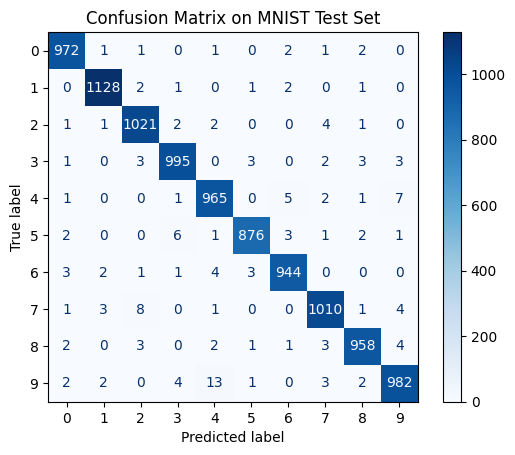

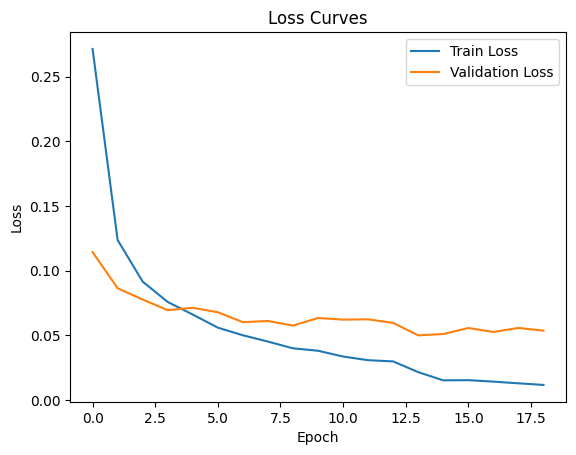

In [7]:
# ============================
# 7. Load best model and evaluate on test set
# ============================
model.load_state_dict(torch.load(best_model_path))
model.eval()

test_correct = 0
test_total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"\nTest Accuracy: {test_acc:.2f}%")

# ============================
# 8. Confusion matrix
# ============================
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix on MNIST Test Set")
plt.show()

# Optional: Plot training & validation loss curves
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')
plt.show()